
🔄 Prophet ile işleniyor: AAPL


15:13:20 - cmdstanpy - INFO - Chain [1] start processing
15:13:20 - cmdstanpy - INFO - Chain [1] done processing
15:13:20 - cmdstanpy - INFO - Chain [1] start processing


   RMSE: 19.52, MAPE: 7.49%

🔄 Prophet ile işleniyor: AMZN


15:13:21 - cmdstanpy - INFO - Chain [1] done processing
15:13:21 - cmdstanpy - INFO - Chain [1] start processing


   RMSE: 23.64, MAPE: 9.87%

🔄 Prophet ile işleniyor: GOOG


...

   RMSE: 44.40, MAPE: 14.75%

🔄 Prophet ile işleniyor: MSFT


15:13:22 - cmdstanpy - INFO - Chain [1] done processing
15:13:23 - cmdstanpy - INFO - Chain [1] start processing


   RMSE: 43.80, MAPE: 7.91%

🔄 Prophet ile işleniyor: TSLA


15:13:23 - cmdstanpy - INFO - Chain [1] done processing


   RMSE: 112.50, MAPE: 25.24%

📊 SONUÇLAR ÖZETİ

AAPL   | RMSE:    19.52 | MAPE:   7.49%

AMZN   | RMSE:    23.64 | MAPE:   9.87%

GOOG   | RMSE:    44.40 | MAPE:  14.75%

MSFT   | RMSE:    43.80 | MAPE:   7.91%

TSLA   | RMSE:   112.50 | MAPE:  25.24%

 Grafik kaydedildi: prophet_forecast_results.png


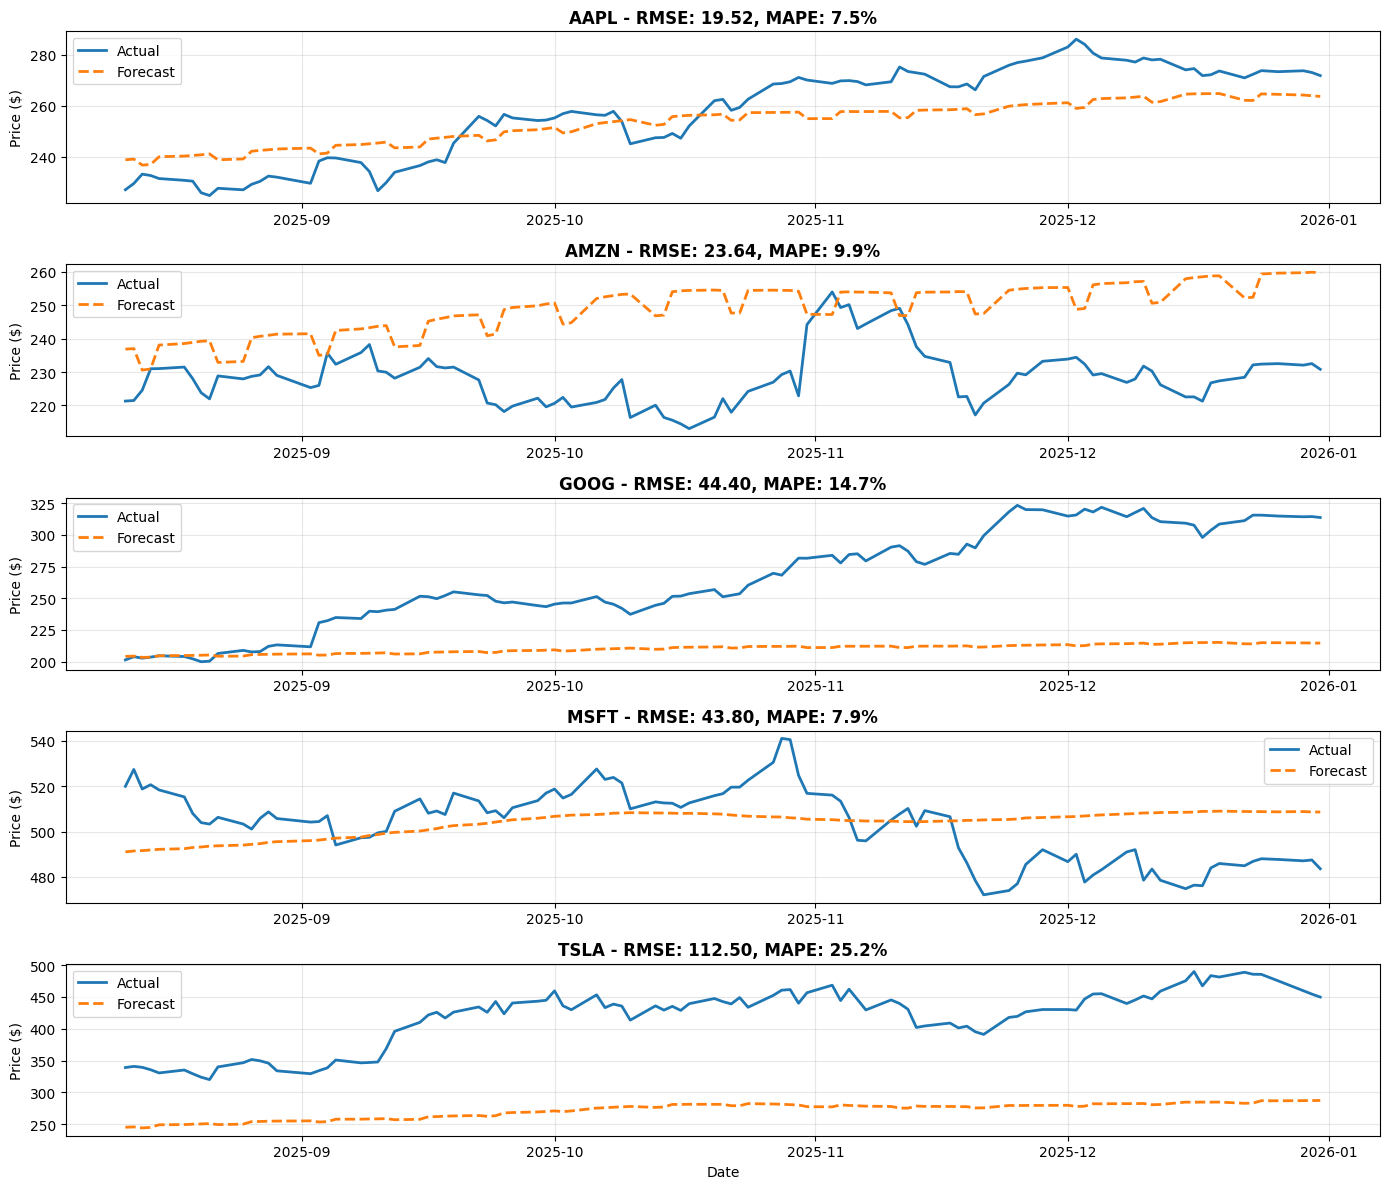

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from prophet import Prophet
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error

# ============================================
# 1. VERİ YÜKLEME
# ============================================
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), ".."))
data_path = os.path.join(BASE_DIR, "data", "stock_data.csv")

df = pd.read_csv(data_path, header=[0,1], index_col=0)
df_close = df["Close"]
df_close.columns = ["AAPL","AMZN","GOOG","MSFT","TSLA"]
df_close = df_close.apply(pd.to_numeric, errors="coerce").dropna()
df_close.index = pd.to_datetime(df_close.index)

# ============================================
# 2. Prophet Forecast
# ============================================
def prophet_forecast(ts, test_days=252):
    df_prophet = ts.reset_index()
    df_prophet.columns = ["ds", "y"]

    train = df_prophet.iloc[:-test_days]
    test = df_prophet.iloc[-test_days:]

    model = Prophet(
        daily_seasonality=False,
        weekly_seasonality=True,
        yearly_seasonality=True
    )
    model.fit(train)

    future = model.make_future_dataframe(periods=test_days, freq='D')
    forecast = model.predict(future)

    pred = forecast.iloc[-test_days:]['yhat'].values
    actual = test['y'].values

    rmse = mean_squared_error(actual, pred, squared=False)
    mape = mean_absolute_percentage_error(actual, pred) * 100

    return actual, pred, test['ds'].values, rmse, mape

# ============================================
# 3. Tüm hisseler için çalıştır
# ============================================
results = {}

for col in df_close.columns:
    print(f"\n🔄 Prophet ile işleniyor: {col}")
    actual, pred, dates, rmse, mape = prophet_forecast(df_close[col])
    results[col] = {"actual": actual, "forecast": pred, "dates": dates, "rmse": rmse, "mape": mape}
    print(f"   RMSE: {rmse:.2f}, MAPE: {mape:.2f}%")

# ============================================
# 4. Sonuçlar
# ============================================
print("\n" + "="*60)
print("📊 SONUÇLAR ÖZETİ")
print("="*60)

for col, res in results.items():
    print(f"\n{col:6s} | RMSE: {res['rmse']:8.2f} | MAPE: {res['mape']:6.2f}%")

# ============================================
# 5. Grafikler
# ============================================
fig, axes = plt.subplots(5, 1, figsize=(14, 12))

for idx, (col, res) in enumerate(results.items()):
    show_days = 100
    axes[idx].plot(res['dates'][-show_days:], res['actual'][-show_days:], label='Actual', linewidth=2)
    axes[idx].plot(res['dates'][-show_days:], res['forecast'][-show_days:], label='Forecast', linestyle='--', linewidth=2)
    axes[idx].set_title(f"{col} - RMSE: {res['rmse']:.2f}, MAPE: {res['mape']:.1f}%", fontsize=12, fontweight='bold')
    axes[idx].legend(loc='best')
    axes[idx].grid(True, alpha=0.3)
    axes[idx].set_ylabel('Price ($)')

axes[-1].set_xlabel('Date')
plt.tight_layout()
plt.savefig('prophet_forecast_results.png', dpi=300, bbox_inches='tight')
print("\n Grafik kaydedildi: prophet_forecast_results.png")
plt.show()
